# CALLCONNECT — END-TO-END SPEECH EMOTION CLASSIFICATION PIPELINE

This notebook implements the complete machine-learning lifecycle for the CallConnect Speech Emotion Classification project,
starting from the raw RAVDESS audio dataset and progressing through data engineering, exploratory analysis, machine learning, prediction, analytics,
and business-level reporting.

The notebook is designed as a *single end-to-end reproducible pipeline*, where each stage produces the data or outputs required by the next stage.

## End-to-End Workflow

### 1. Raw Data Acquisition — Data Engineer

* Load the RAVDESS speech emotion audio dataset.
* Locate and identify all valid `.wav` recordings.
* Verify the availability, structure, and completeness of the raw dataset.
* Extract metadata such as actor ID and emotion label from the audio filenames.

### 2. Data Validation and Preprocessing — Data Engineer

* Validate audio files and identify corrupt or unreadable recordings.
* Check for missing values, infinite values, duplicate records, and duplicate file paths.
* Load and preprocess the audio recordings.
* Handle invalid or failed audio files appropriately.
* Perform data-quality and schema validation.
* Ensure that preprocessing does not introduce data leakage.

### 3. Audio Feature Extraction — Data Engineer

Extract audio characteristics from each valid recording using:

* **40 MFCC features**
* **12 Chroma features**
* **128 Mel-spectrogram features**

This produces **180 audio features per recording**, which are combined with metadata to create the processed feature dataset.

### 4. Exploratory Data Analysis — Data Analyst

* Examine the structure and distribution of the processed dataset.
* Analyze the distribution of the eight emotion classes.
* Examine feature distributions and identify potential outliers or anomalies.
* Analyze correlations between selected audio features.
* Generate visualizations to understand patterns within the dataset.
* Identify key insights that may influence the modelling strategy.

### 5. Dataset Preparation — Data Engineer / Data Scientist

* Separate input features and target labels.
* Perform an **actor-independent train/test split** so that recordings from the same actor do not occur in both sets.
* Prepare the feature matrices for machine learning.
* Apply feature scaling using parameters learned only from the training data.
* Verify that the final training and test datasets are suitable for model development.

### 6. Model Training and Comparison — Data Scientist

* Establish baseline machine-learning models.
* Train multiple candidate classification algorithms.
* Compare model performance using appropriate evaluation metrics.
* Use cross-validation to obtain reliable performance estimates.
* Analyze accuracy, precision, recall, F1-score, macro F1-score, and confusion matrices.
* Compare the models based on their measured performance without introducing test-set leakage.

### 7. Hyperparameter Tuning and Final Model — Data Scientist

* Select the model configuration for further optimization based on the development results.
* Perform hyperparameter tuning using cross-validation.
* Identify the optimized model parameters.
* Retrain the final model using the appropriate training data.
* Evaluate the final model on the held-out test dataset.
* Save the trained model for reproducible inference.

### 8. Reproducible Inference and Prediction — ML Engineer

* Load the saved final model and required preprocessing components.
* Create a structured prediction pipeline from processed input data to model output.
* Generate predictions for the test recordings.
* Generate class probabilities where supported by the model.
* Calculate prediction confidence.
* Record inference time for each prediction.
* Validate that the inference pipeline produces consistent and correctly formatted outputs.
* Save the final prediction results as a structured CSV file.

### 9. Analytics Engineering — Analytics Engineer

* Validate the model prediction output.
* Transform predictions into analytics-ready datasets.
* Calculate overall and per-emotion performance metrics.
* Analyze prediction confidence and classification errors.
* Construct a confusion-cost matrix to represent the project-defined business impact of different classification errors.
* Perform decision-threshold analysis using model probabilities.
* Calculate relevant business KPIs and derived metrics.
* Generate summary datasets for business intelligence and reporting.

### 10. Business Intelligence and Visualization — BI / Power BI Developer

* Connect the analytics-ready outputs to the dashboard layer.
* Present key model and business KPIs through interactive visualizations.
* Display emotion-level performance and prediction distributions.
* Visualize confidence levels and classification errors.
* Provide filters and interactive exploration of the results.
* Implement a single-record prediction tester or what-if analysis where applicable.
* Present the final results in an executive-readable format.

### 11. Final End-to-End Output

The completed notebook connects the entire workflow:

**Raw Audio → Data Validation → Preprocessing → Feature Extraction → EDA → Dataset Preparation → Model Training → Model Tuning → Final Model → Prediction → Analytics → Business KPIs → BI Dashboard**

The objective is to demonstrate a **complete, reproducible machine-learning lifecycle**, where the output of each stage becomes the input for the next stage, ultimately transforming raw speech recordings into validated emotion predictions, analytics metrics, and business-ready insights.


In [1]:
# ============================================================
# RAVDESS DATA PREPROCESSING
# Purpose:
# 1. Read raw RAVDESS audio files
# 2. Extract metadata from filenames
# 3. Extract audio features
# 4. Save processed features as CSV
# 5. Check preprocessing/data quality
# ============================================================

import os
import glob
import warnings

import numpy as np
import pandas as pd
import librosa

from tqdm import tqdm

warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# 1. CONFIGURATION
# ============================================================

DATA_PATH = r"D:\SJU\ML assn\Audio_Speech_Actors_01-24_16k"


In [3]:
# ============================================================
# 2. EMOTION MAPPING
# ============================================================

EMOTION_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

In [4]:
# ============================================================
# 3. FEATURE EXTRACTION
# ============================================================

def extract_features(file_name):
    """
    Load an audio file and extract numerical audio features.

    Features extracted:
    - 40 MFCC features
    - 12 Chroma features
    - 128 Mel-spectrogram features

    Returns:
        numpy array containing all extracted features.
    """

    # Load audio file
    X, sample_rate = librosa.load(file_name, sr=None)

    # Short-Time Fourier Transform
    stft = np.abs(librosa.stft(X))

    # --------------------------------------------------------
    # MFCC
    # --------------------------------------------------------

    mfccs = np.mean(
        librosa.feature.mfcc(
            y=X,
            sr=sample_rate,
            n_mfcc=40
        ).T,
        axis=0
    )

    # --------------------------------------------------------
    # Chroma
    # --------------------------------------------------------

    chroma = np.mean(
        librosa.feature.chroma_stft(
            S=stft,
            sr=sample_rate
        ).T,
        axis=0
    )

    # --------------------------------------------------------
    # Mel-Spectrogram
    # --------------------------------------------------------

    mel = np.mean(
        librosa.feature.melspectrogram(
            y=X,
            sr=sample_rate
        ).T,
        axis=0
    )

    # Combine all features into one feature vector
    result = np.hstack((mfccs, chroma, mel))

    return result


def get_feature_names():
    """
    Generate column names corresponding to the extracted features.
    """

    return (
        [f"mfcc_{i}" for i in range(40)]
        + [f"chroma_{i}" for i in range(12)]
        + [f"mel_{i}" for i in range(128)]
    )

In [5]:
# ============================================================
# 4. PROCESS RAVDESS FILES
# ============================================================

def process_dataset():
    """
    Process all RAVDESS audio files.

    For each audio file:
    1. Read metadata from the filename
    2. Extract audio features
    3. Validate the extracted features
    4. Store metadata and features in a dataframe

    Returns:
        features_df: Processed feature dataframe
        corrupt_files: List of files that could not be processed
    """

    records = []
    corrupt_files = []

    # Find all RAVDESS audio files
    files = glob.glob(
        os.path.join(DATA_PATH, "Actor_*", "*.wav")
    )

    if not files:
        raise FileNotFoundError(
            f"No .wav files found under {DATA_PATH}"
        )

    print(f"Found {len(files)} audio files.")

    # Process each audio file
    for file in tqdm(files, desc="Extracting features"):

        file_name = os.path.basename(file)

        try:
            # ------------------------------------------------
            # Extract metadata from filename
            # RAVDESS format:
            # 03-01-05-01-02-02-12-01.wav
            #              ↑
            #            Actor
            # ------------------------------------------------

            parts = file_name.split("-")

            if len(parts) != 7:
                raise ValueError("Invalid RAVDESS filename format")

            emotion_code = parts[2]
            actor_id = parts[6].replace(".wav", "")

            # Check whether emotion code is valid
            if emotion_code not in EMOTION_MAP:
                raise ValueError(
                    f"Unknown emotion code: {emotion_code}"
                )

            emotion = EMOTION_MAP[emotion_code]

            # ------------------------------------------------
            # Extract audio features
            # ------------------------------------------------

            feature = extract_features(file)

            # ------------------------------------------------
            # Feature validation
            # Expected:
            # 40 MFCC + 12 Chroma + 128 Mel = 180 features
            # ------------------------------------------------

            if feature.shape[0] != 180:
                raise ValueError(
                    f"Expected 180 features, got {feature.shape[0]}"
                )

            if np.isnan(feature).any():
                raise ValueError("NaN values found in features")

            if np.isinf(feature).any():
                raise ValueError("Infinite values found in features")

            # ------------------------------------------------
            # Store metadata + features
            # ------------------------------------------------

            record = {
                "file_path": file,
                "actor_id": actor_id,
                "emotion": emotion
            }

            # Add feature values
            feature_names = get_feature_names()

            for name, value in zip(feature_names, feature):
                record[name] = value

            records.append(record)

        except Exception as e:

            corrupt_files.append(file)

            print(
                f"[WARN] Skipping {file}: {e}"
            )

    # Create dataframe
    features_df = pd.DataFrame(records)

    return features_df, corrupt_files

In [6]:
# ============================================================
# 5. FEATURE COLUMN NAMES
# ============================================================

def get_feature_names():
    """
    Return column names for all extracted audio features.

    Total:
    40 MFCC + 12 Chroma + 128 Mel = 180 features
    """

    return (
        [f"mfcc_{i}" for i in range(40)]
        + [f"chroma_{i}" for i in range(12)]
        + [f"mel_{i}" for i in range(128)]
    )

In [7]:
def load_data():
    x, y, file_log = [], [], []
    corrupt_files = []

    files = glob.glob(
        os.path.join(DATA_PATH, "Actor_*", "*.wav")
    )

    if not files:
        raise FileNotFoundError(
            f"No .wav files found under {DATA_PATH}"
        )

    for file in tqdm(files, desc="Extracting features"):

        file_name = os.path.basename(file)
        parts = file_name.split("-")

        try:
            # Extract metadata from RAVDESS filename
            emotion_code = parts[2]
            actor_id = parts[6].replace(".wav", "")

            emotion = EMOTION_MAP[emotion_code]

            # Extract audio features
            feature = extract_features(file)

            # Schema validation:
            # 40 MFCC + 12 Chroma + 128 Mel = 180 features
            if (
                feature.shape[0] != 180
                or np.isnan(feature).any()
                or np.isinf(feature).any()
            ):
                corrupt_files.append(file)
                continue

            # Store features
            x.append(feature)

            # Store metadata
            y.append(emotion)

            file_log.append({
                "file": file,
                "actor_id": actor_id,
                "emotion": emotion
            })

        except Exception as e:
            corrupt_files.append(file)

            print(
                f"[WARN] Skipping {file}: {e}"
            )

    # Convert extracted features to NumPy array
    X = np.array(x)

    # Create feature column names
    feature_names = get_feature_names()

    # Create dataframe
    features_df = pd.DataFrame(
        X,
        columns=feature_names
    )

    # Add metadata
    log_df = pd.DataFrame(file_log)

    features_df.insert(
        0,
        "emotion",
        log_df["emotion"].values
    )

    features_df.insert(
        0,
        "actor_id",
        log_df["actor_id"].values
    )

    features_df.insert(
        0,
        "file_path",
        log_df["file"].values
    )

    return features_df, corrupt_files

In [8]:
# ============================================================
# 7. DATA QUALITY LOG & AUDIT
# ============================================================

def write_quality_log(features_df, corrupt_files, elapsed_s):
    """
    Create a data quality audit log for the preprocessing stage.

    Checks:
    - Number of raw files processed
    - Number of corrupt/skipped files
    - Expected file count
    - Missing values
    - Infinite values
    - Duplicate rows
    - Duplicate file paths
    - Feature dimensions
    - Number of actors
    - Emotion distribution
    """

    feature_columns = get_feature_names()

    lines = []

    lines.append("DATA QUALITY LOG & AUDIT SHEET")
    lines.append("=" * 45)

    # --------------------------------------------------------
    # Basic dataset information
    # --------------------------------------------------------

    lines.append(f"Source path          : {DATA_PATH}")
    lines.append(f"Extraction time      : {elapsed_s:.1f}s")

    lines.append(f"Total usable files   : {len(features_df)}")
    lines.append(f"Corrupt/skipped      : {len(corrupt_files)}")

    # --------------------------------------------------------
    # Feature information
    # --------------------------------------------------------

    lines.append(
        f"Feature dimensions   : {len(feature_columns)} "
        f"(40 MFCC + 12 Chroma + 128 Mel)"
    )

    # --------------------------------------------------------
    # Missing values
    # --------------------------------------------------------

    missing_values = (
        features_df[feature_columns]
        .isna()
        .sum()
        .sum()
    )

    lines.append(
        f"Missing feature values : {int(missing_values)}"
    )

    # --------------------------------------------------------
    # Infinite values
    # --------------------------------------------------------

    infinite_values = np.isinf(
        features_df[feature_columns].values
    ).sum()

    lines.append(
        f"Infinite feature values: {int(infinite_values)}"
    )

    # --------------------------------------------------------
    # Duplicate checks
    # --------------------------------------------------------

    duplicate_rows = features_df.duplicated().sum()

    duplicate_files = (
        features_df["file_path"]
        .duplicated()
        .sum()
    )

    lines.append(
        f"Duplicate rows        : {int(duplicate_rows)}"
    )

    lines.append(
        f"Duplicate file paths  : {int(duplicate_files)}"
    )

    # --------------------------------------------------------
    # Actor information
    # --------------------------------------------------------

    unique_actors = features_df["actor_id"].nunique()

    lines.append(
        f"Unique actors         : {unique_actors}"
    )

    # --------------------------------------------------------
    # Emotion distribution
    # --------------------------------------------------------

    lines.append("")
    lines.append("Emotion distribution:")

    emotion_counts = (
        features_df["emotion"]
        .value_counts()
        .sort_index()
    )

    for emotion, count in emotion_counts.items():
        lines.append(
            f"  {emotion:15s} {count}"
        )

    # --------------------------------------------------------
    # Preprocessing validation
    # --------------------------------------------------------

    lines.append("")
    lines.append("Preprocessing validation:")

    # RAVDESS contains 1,440 audio files
    expected_files = 1440

    # Check whether all expected files were processed
    if (
        len(features_df) == expected_files
        and len(corrupt_files) == 0
    ):
        lines.append(
            "  File count check    : PASSED"
        )
    else:
        lines.append(
            f"  File count check    : REVIEW "
            f"(expected {expected_files}, "
            f"got {len(features_df)})"
        )

    # Overall preprocessing status
    if (
        len(features_df) == expected_files
        and len(corrupt_files) == 0
        and missing_values == 0
        and infinite_values == 0
        and duplicate_rows == 0
        and duplicate_files == 0
    ):
        lines.append("  STATUS: PASSED")
    else:
        lines.append("  STATUS: REVIEW REQUIRED")

    # --------------------------------------------------------
    # Save audit log
    # --------------------------------------------------------

    log_text = "\n".join(lines)

    log_file = os.path.join(
        OUTPUT_PATH,
        "data_quality_log.txt"
    )

    with open(log_file, "w") as f:
        f.write(log_text)

    print(log_text)
    print(f"\nAudit log saved to: {log_file}")

In [9]:
# ============================================================
# 8. MAIN PREPROCESSING PIPELINE
# ============================================================
# ============================================================
# PROJECT PATHS
# ============================================================

import os

OUTPUT_PATH = r"D:\SJU\ML assn\CallConnect\outputs\Data_preprocessing"

os.makedirs(
    OUTPUT_PATH,
    exist_ok=True
)

import time
from sklearn.model_selection import train_test_split


def main():

    # Start timer
    t0 = time.time()

    # --------------------------------------------------------
    # 1. Extract features and metadata from raw audio
    # --------------------------------------------------------

    features_df, corrupt_files = load_data()

    # --------------------------------------------------------
    # 2. Schema validation
    # --------------------------------------------------------

    expected_metadata = [
        "file_path",
        "actor_id",
        "emotion"
    ]

    expected_features = get_feature_names()

    expected_columns = (
        expected_metadata +
        expected_features
    )

    missing_columns = [
        col
        for col in expected_columns
        if col not in features_df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing expected columns: {missing_columns}"
        )

    print("Schema validation: PASSED")

    # --------------------------------------------------------
    # 3. Save corrupt/skipped files
    # --------------------------------------------------------

    if corrupt_files:
        pd.DataFrame(
            {"corrupt_file": corrupt_files}
        ).to_csv(
            os.path.join(
                OUTPUT_PATH,
                "corrupt_files.csv"
            ),
            index=False
        )

    # --------------------------------------------------------
    # 5. Create stratified train/test split
    # --------------------------------------------------------

    train_df, test_df = train_test_split(
        features_df,
        test_size=0.20,
        random_state=42,
        stratify=features_df["emotion"]
    )

    # --------------------------------------------------------
    # 7. Generate data quality audit
    # --------------------------------------------------------

    elapsed = time.time() - t0

    write_quality_log(
        features_df,
        corrupt_files,
        elapsed
    )

    # --------------------------------------------------------
    # 8. Final summary
    # --------------------------------------------------------

    print("\n========================================")
    print("PREPROCESSING COMPLETE")
    print("========================================")

    print(f"Valid files       : {len(features_df)}")
    print(f"Corrupt files     : {len(corrupt_files)}")
    print(f"Feature columns   : {len(get_feature_names())}")
    print(f"Processing time   : {elapsed:.1f} seconds")

    print("\nDataset split:")
    print(f"Training samples  : {len(train_df)}")
    print(f"Testing samples   : {len(test_df)}")

    # --------------------------------------------------------
    # 9. Return datasets for downstream stages
    # --------------------------------------------------------

    return features_df, train_df, test_df, corrupt_files

features_df, train_df, test_df, corrupt_files = main()

Extracting features: 100%|██████████| 1440/1440 [00:50<00:00, 28.76it/s]


Schema validation: PASSED
DATA QUALITY LOG & AUDIT SHEET
Source path          : D:\SJU\ML assn\Audio_Speech_Actors_01-24_16k
Extraction time      : 50.2s
Total usable files   : 1440
Corrupt/skipped      : 0
Feature dimensions   : 180 (40 MFCC + 12 Chroma + 128 Mel)
Missing feature values : 0
Infinite feature values: 0
Duplicate rows        : 0
Duplicate file paths  : 0
Unique actors         : 24

Emotion distribution:
  angry           192
  calm            192
  disgust         192
  fearful         192
  happy           192
  neutral         96
  sad             192
  surprised       192

Preprocessing validation:
  File count check    : PASSED
  STATUS: PASSED

Audit log saved to: D:\SJU\ML assn\CallConnect\outputs\Data_preprocessing\data_quality_log.txt

PREPROCESSING COMPLETE
Valid files       : 1440
Corrupt files     : 0
Feature columns   : 180
Processing time   : 50.2 seconds

Dataset split:
Training samples  : 1152
Testing samples   : 288


# EDA

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [11]:
# ============================================================
# B1. DATA ANALYST (DA) — LOAD PROCESSED DATA
# ============================================================

# Use the DataFrame returned by the DE stage
df = features_df.copy()

metadata_columns = [
    "file_path",
    "actor_id",
    "emotion"
]

feature_columns = [
    col for col in df.columns
    if col not in metadata_columns
]

print("EDA dataset shape:", df.shape)
print("Number of metadata columns:", len(metadata_columns))
print("Number of feature columns:", len(feature_columns))

df.head()

EDA dataset shape: (1440, 183)
Number of metadata columns: 3
Number of feature columns: 180


,file_path,actor_id,emotion,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,...,mel_118,mel_119,mel_120,mel_121,mel_122,mel_123,mel_124,mel_125,mel_126,mel_127
0,D:\SJU\ML assn\Audio_Speech_Actors_01-24_16k\A...,01,neutral,-693.705994,50.268967,0.389445,14.521958,3.166481,-2.484452,-4.226547,...,0.000007,0.000005,0.000004,0.000003,0.000003,0.000003,0.000003,0.000004,0.000002,0.000001
1,D:\SJU\ML assn\Audio_Speech_Actors_01-24_16k\A...,01,neutral,-683.443848,49.043922,-1.755556,19.273504,1.881828,-0.790472,-4.822916,...,0.000014,0.000006,0.000004,0.000004,0.000003,0.000003,0.000004,0.000003,0.000002,0.000002
2,D:\SJU\ML assn\Audio_Speech_Actors_01-24_16k\A...,01,neutral,-678.002808,51.673199,-0.249662,14.532812,0.572283,-0.074813,-6.300016,...,0.000062,0.000037,0.000019,0.000023,0.000019,0.000016,0.000011,0.000009,0.000005,0.000003
3,D:\SJU\ML assn\Audio_Speech_Actors_01-24_16k\A...,01,neutral,-674.198730,50.815395,1.671904,14.465610,2.909083,1.706151,-7.525471,...,0.000048,0.000019,0.000014,0.000011,0.000014,0.000020,0.000018,0.000011,0.000009,0.000008
4,D:\SJU\ML assn\Audio_Speech_Actors_01-24_16k\A...,01,calm,-709.260925,55.990372,2.472364,16.629053,3.192599,-0.967488,-5.935109,...,0.000014,0.000006,0.000006,0.000004,0.000004,0.000004,0.000003,0.000003,0.000003,0.000002


In [12]:
# ============================================================
# 3. MISSING VALUES
# ============================================================

print("\n" + "=" * 50)
print("1. MISSING VALUES")
print("=" * 50)

missing_total = df.isnull().sum().sum()

print("Total missing values:", missing_total)

if missing_total == 0:
    print("STATUS: PASSED - No missing values found.")
else:
    print("\nColumns with missing values:")
    print(
        df.isnull()
        .sum()
        .loc[lambda x: x > 0]
    )



1. MISSING VALUES
Total missing values: 0
STATUS: PASSED - No missing values found.


In [13]:
# ============================================================
# 4. DUPLICATES
# ============================================================

print("\n" + "=" * 50)
print("2. DUPLICATES")
print("=" * 50)

duplicate_rows = df.duplicated().sum()
duplicate_paths = df["file_path"].duplicated().sum()

print("Duplicate rows:", duplicate_rows)
print("Duplicate file paths:", duplicate_paths)

if duplicate_rows == 0 and duplicate_paths == 0:
    print("STATUS: PASSED - No duplicates found.")
else:
    print("STATUS: REVIEW REQUIRED")



2. DUPLICATES
Duplicate rows: 0
Duplicate file paths: 0
STATUS: PASSED - No duplicates found.


In [15]:
# ============================================================
# 5. OUTLIER ANALYSIS - IQR METHOD
# ============================================================

print("\n" + "=" * 50)
print("3. OUTLIER ANALYSIS")
print("=" * 50)

outlier_results = []

for feature in feature_columns:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    )

    outlier_count = outliers.sum()

    outlier_percentage = (
        outlier_count / len(df)
    ) * 100

    outlier_results.append({
        "feature": feature,
        "outlier_count": outlier_count,
        "outlier_percentage": outlier_percentage
    })


outlier_df = pd.DataFrame(outlier_results)

outlier_df = outlier_df.sort_values(
    "outlier_percentage",
    ascending=False
)

print("\nTop 10 features with most statistical outliers:")
print(
    outlier_df.head(10).to_string(index=False)
)




3. OUTLIER ANALYSIS

Top 10 features with most statistical outliers:
feature  outlier_count  outlier_percentage
  mel_0            297           20.625000
 mel_66            251           17.430556
 mel_78            251           17.430556
  mel_1            250           17.361111
 mel_57            248           17.222222
 mel_84            246           17.083333
 mel_58            245           17.013889
 mel_83            245           17.013889
 mel_86            244           16.944444
 mel_45            244           16.944444


In [16]:
# ============================================================
# 6. OUTLIER SUMMARY
# ============================================================

features_with_outliers = (
    outlier_df["outlier_count"] > 0
).sum()

print("\nFeatures containing statistical outliers:",
      features_with_outliers,
      "out of",
      len(feature_columns))

print(
    "\nNote: Statistical outliers are not automatically"
    " treated as errors. They are only flagged for review."
)




Features containing statistical outliers: 177 out of 180

Note: Statistical outliers are not automatically treated as errors. They are only flagged for review.


# ML Analysis

In [17]:
import pandas as pd
import numpy as np
import pickle
import warnings
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

In [18]:
import warnings
warnings.filterwarnings("ignore")

# ==========================================================
# LOAD OFFICIAL TRAIN / TEST DATA FROM DATA ENGINEERING
# ==========================================================

train_df = train_df.copy()
test_df = test_df.copy()

print("Training dataset shape:", train_df.shape)
print("Testing dataset shape :", test_df.shape)

# ----------------------------------------------------------
# Separate features and target
# ----------------------------------------------------------

metadata_columns = [
    "file_path",
    "actor_id",
    "emotion"
]

feature_columns = [
    col for col in train_df.columns
    if col not in metadata_columns
]

X_train = train_df[feature_columns]
y_train = train_df["emotion"]

X_test = test_df[feature_columns]
y_test = test_df["emotion"]

# ----------------------------------------------------------
# Verify dimensions
# ----------------------------------------------------------

print("\nNumber of features:", len(feature_columns))
print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training dataset shape: (1152, 183)
Testing dataset shape : (288, 183)

Number of features: 180
Training samples: 1152
Test samples: 288

Training class distribution:
emotion
disgust      154
angry        154
sad          154
calm         154
happy        153
surprised    153
fearful      153
neutral       77
Name: count, dtype: int64

Test class distribution:
emotion
happy        39
fearful      39
surprised    39
sad          38
calm         38
angry        38
disgust      38
neutral      19
Name: count, dtype: int64


In [19]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# BASELINE SVM — UNTUNED
# ============================================================

svm_baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])

# ============================================================
# 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}

svm_cv = cross_validate(
    svm_baseline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

# ============================================================
# CV RESULTS
# ============================================================

cv_train_acc = svm_cv["train_accuracy"].mean()
cv_accuracy = svm_cv["test_accuracy"].mean()
cv_precision = svm_cv["test_precision"].mean()
cv_recall = svm_cv["test_recall"].mean()
cv_f1 = svm_cv["test_f1"].mean()

# ============================================================
# FIT BASELINE SVM ON COMPLETE TRAINING SET
# ============================================================

svm_baseline.fit(X_train, y_train)

# ============================================================
# PREDICTIONS
# ============================================================

y_train_pred = svm_baseline.predict(X_train)
y_test_pred = svm_baseline.predict(X_test)

# ============================================================
# FINAL TEST METRICS
# ============================================================

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred,
    average="macro"
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    average="macro"
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro"
)

# ============================================================
# DISPLAY RESULTS
# ============================================================

print("BASELINE SVM (RBF, DEFAULT PARAMETERS)")
print("=" * 55)

print(
    f"Training Accuracy:      "
    f"{train_accuracy:.4f} ({train_accuracy * 100:.2f}%)"
)

print(
    f"CV Accuracy:            "
    f"{cv_accuracy:.4f} ({cv_accuracy * 100:.2f}%)"
)

print(
    f"Test Accuracy:          "
    f"{test_accuracy:.4f} ({test_accuracy * 100:.2f}%)"
)

print(
    f"\nCV Macro F1:            "
    f"{cv_f1:.4f}"
)

print(
    f"Test Macro F1:          "
    f"{test_f1:.4f}"
)

print(
    f"Test Macro Precision:   "
    f"{test_precision:.4f}"
)

print(
    f"Test Macro Recall:      "
    f"{test_recall:.4f}"
)

print(
    f"\nTrain-Test Gap:         "
    f"{(train_accuracy - test_accuracy) * 100:.2f}%"
)

BASELINE SVM (RBF, DEFAULT PARAMETERS)
Training Accuracy:      0.6172 (61.72%)
CV Accuracy:            0.4557 (45.57%)
Test Accuracy:          0.4340 (43.40%)

CV Macro F1:            0.4080
Test Macro F1:          0.3929
Test Macro Precision:   0.3927
Test Macro Recall:      0.4071

Train-Test Gap:         18.32%


# Fine Tuning SVM

In [20]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])

param_grid = {
    "model__C": [5, 10, 15, 20, 30],
    "model__gamma": [0.001, 0.003, 0.005, 0.01, 0.02]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    refit=True,
    verbose=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\nBEST PARAMETERS:")
print(grid.best_params_)

print("\nBEST CV MACRO F1:")
print(f"{grid.best_score_:.4f}")
print(f"{grid.best_score_ * 100:.2f}%")

Fitting 5 folds for each of 25 candidates, totalling 125 fits

BEST PARAMETERS:
{'model__C': 5, 'model__gamma': 0.02}

BEST CV MACRO F1:
0.6181
61.81%


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Best tuned SVM
best_svm = grid.best_estimator_

# Predictions
y_train_pred_tuned = best_svm.predict(X_train)
y_test_pred_tuned = best_svm.predict(X_test)

# Metrics
train_accuracy_tuned = accuracy_score(
    y_train, y_train_pred_tuned
)

test_accuracy_tuned = accuracy_score(
    y_test, y_test_pred_tuned
)

test_precision_tuned = precision_score(
    y_test,
    y_test_pred_tuned,
    average="macro"
)

test_recall_tuned = recall_score(
    y_test,
    y_test_pred_tuned,
    average="macro"
)

test_f1_tuned = f1_score(
    y_test,
    y_test_pred_tuned,
    average="macro"
)

train_test_gap_tuned = (
    train_accuracy_tuned - test_accuracy_tuned
)

# --------------------------------------------------
# RESULTS
# --------------------------------------------------

print("TUNED SVM RESULTS")
print("=" * 55)

print(f"Best Parameters: {grid.best_params_}")

print(
    f"\nTraining Accuracy:     "
    f"{train_accuracy_tuned:.4f} "
    f"({train_accuracy_tuned*100:.2f}%)"
)

print(
    f"CV Macro F1:           "
    f"{grid.best_score_:.4f} "
    f"({grid.best_score_*100:.2f}%)"
)

print(
    f"Test Accuracy:         "
    f"{test_accuracy_tuned:.4f} "
    f"({test_accuracy_tuned*100:.2f}%)"
)

print(
    f"Test Macro F1:         "
    f"{test_f1_tuned:.4f} "
    f"({test_f1_tuned*100:.2f}%)"
)

print(
    f"Test Macro Precision:   "
    f"{test_precision_tuned:.4f} "
    f"({test_precision_tuned*100:.2f}%)"
)

print(
    f"Test Macro Recall:      "
    f"{test_recall_tuned:.4f} "
    f"({test_recall_tuned*100:.2f}%)"
)

print(
    f"Train-Test Gap:        "
    f"{train_test_gap_tuned*100:.2f}%"
)

# --------------------------------------------------
# CLASSIFICATION REPORT
# --------------------------------------------------

print("\nCLASSIFICATION REPORT")
print("=" * 55)

print(
    classification_report(
        y_test,
        y_test_pred_tuned
    )
)

TUNED SVM RESULTS
Best Parameters: {'model__C': 5, 'model__gamma': 0.02}

Training Accuracy:     0.9931 (99.31%)
CV Macro F1:           0.6181 (61.81%)
Test Accuracy:         0.6493 (64.93%)
Test Macro F1:         0.6381 (63.81%)
Test Macro Precision:   0.6761 (67.61%)
Test Macro Recall:      0.6354 (63.54%)
Train-Test Gap:        34.38%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       0.64      0.79      0.71        38
        calm       0.71      0.84      0.77        38
     disgust       0.62      0.74      0.67        38
     fearful       0.53      0.67      0.59        39
       happy       0.58      0.46      0.51        39
     neutral       0.89      0.42      0.57        19
         sad       0.68      0.45      0.54        38
   surprised       0.76      0.72      0.74        39

    accuracy                           0.65       288
   macro avg       0.68      0.64      0.64       288
weighted avg       0.66      0.65      0.


CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       0.64      0.79      0.71        38
        calm       0.71      0.84      0.77        38
     disgust       0.62      0.74      0.67        38
     fearful       0.53      0.67      0.59        39
       happy       0.58      0.46      0.51        39
     neutral       0.89      0.42      0.57        19
         sad       0.68      0.45      0.54        38
   surprised       0.76      0.72      0.74        39

    accuracy                           0.65       288
   macro avg       0.68      0.64      0.64       288
weighted avg       0.66      0.65      0.64       288



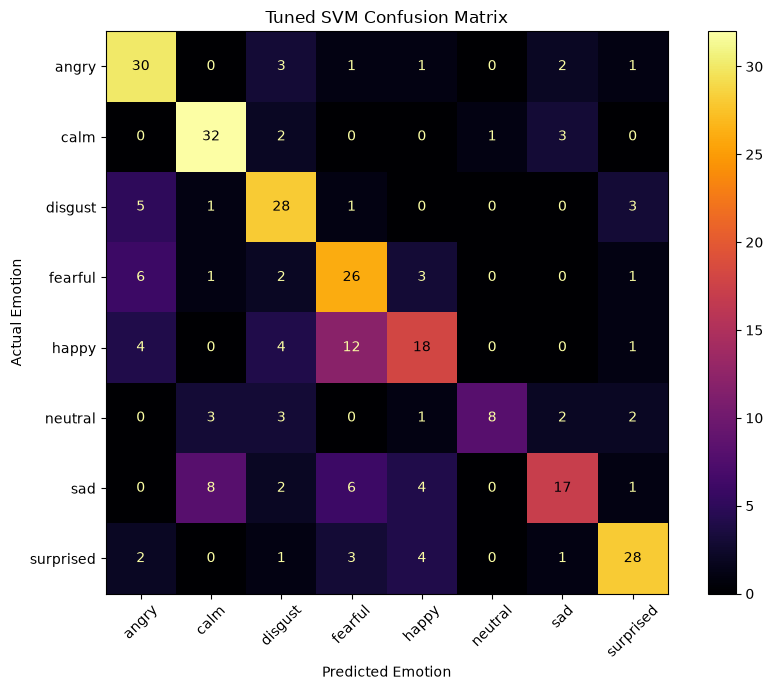

In [24]:
# ----------------------------------------------------------
# CLASSIFICATION REPORT + CONFUSION MATRIX
# ----------------------------------------------------------

import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ----------------------------------------------------------
# CLASSIFICATION REPORT
# ----------------------------------------------------------

print("\nCLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_test_pred_tuned
    )
)

# ----------------------------------------------------------
# CONFUSION MATRIX
# ----------------------------------------------------------

classes = sorted(y_test.unique())

cm = confusion_matrix(
    y_test,
    y_test_pred_tuned,
    labels=classes
)

fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    ax=ax,
    cmap="inferno",
    values_format="d",
    xticks_rotation=45
)

plt.title("Tuned SVM Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.tight_layout()
plt.show()

In [25]:
import joblib

final_model = grid.best_estimator_

MODEL_PATH = r"D:\SJU\ML assn\CallConnect\models\final_svm_model.pkl"

joblib.dump(final_model, MODEL_PATH)

print("Final model saved to:")
print(MODEL_PATH)

print("\nProbability support:")
print(hasattr(final_model, "predict_proba"))

print("\nBest parameters:")
print(grid.best_params_)

Final model saved to:
D:\SJU\ML assn\CallConnect\models\final_svm_model.pkl

Probability support:
True

Best parameters:
{'model__C': 5, 'model__gamma': 0.02}


In [26]:
# ----------------------------------------------------------
# VERIFY CURRENT MODEL
# ----------------------------------------------------------

test_predictions = best_svm.predict(X_test)

print("Model prediction completed.")
print(
    "Predictions match:",
    (test_predictions == y_test_pred_tuned).all()
)

Model prediction completed.
Predictions match: True


# ML Engineering — Inference Pipeline

The final tuned SVM model is integrated into a reusable inference pipeline for batch and single-audio prediction.

The inference pipeline provides:
- Emotion prediction
- Class-wise probability estimates
- Prediction confidence
- Inference latency measurement
- Structured prediction results for downstream analytics

In [27]:
# ============================================================
# ML ENGINEERING — OUTPUT CONFIGURATION
# ============================================================

from pathlib import Path
import time
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd()

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "ML_Engineering"
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("ML Engineering output directory:")
print(OUTPUT_DIR)

ML Engineering output directory:
C:\Users\navin\Documents\ML Lab\outputs\ML_Engineering


## Batch Inference on the Held-Out Test Set

The final saved SVM model is used to generate predictions for the held-out test data.

The inference stage does not retrain the model. It only applies the finalized model to previously unseen test samples.

In [28]:
# ============================================================
# BATCH INFERENCE
# ============================================================

start_time = time.perf_counter()

y_test_predictions = final_model.predict(X_test)

# Probability estimates
y_test_probabilities = final_model.predict_proba(X_test)

end_time = time.perf_counter()

total_inference_time_ms = (
    end_time - start_time
) * 1000

average_inference_time_ms = (
    total_inference_time_ms / len(X_test)
)

print("Batch inference completed.")
print(f"Samples processed: {len(X_test)}")
print(
    f"Total inference time: "
    f"{total_inference_time_ms:.2f} ms"
)
print(
    f"Average inference time per sample: "
    f"{average_inference_time_ms:.4f} ms"
)

Batch inference completed.
Samples processed: 288
Total inference time: 215.28 ms
Average inference time per sample: 0.7475 ms


## Structured Prediction Results

The predictions and probability estimates are organized into a structured DataFrame so that the results can be used by downstream analytics.

In [29]:
# ============================================================
# CREATE STRUCTURED PREDICTION RESULTS
# ============================================================

prediction_results = pd.DataFrame({
    "actual_emotion": np.asarray(y_test),
    "predicted_emotion": y_test_predictions,
    "prediction_confidence": y_test_probabilities.max(axis=1),
    "inference_time_ms": average_inference_time_ms
})

# Add probability for each emotion
for i, emotion in enumerate(final_model.classes_):
    prediction_results[
        f"{emotion}_probability"
    ] = y_test_probabilities[:, i]

prediction_results.head()

,actual_emotion,predicted_emotion,prediction_confidence,inference_time_ms,angry_probability,calm_probability,disgust_probability,fearful_probability,happy_probability,neutral_probability,sad_probability,surprised_probability
0,sad,surprised,0.459754,0.747514,0.083064,0.003484,0.090649,0.042428,0.242001,0.011092,0.067528,0.459754
1,calm,calm,0.518521,0.747514,0.009748,0.518521,0.046039,0.012788,0.016030,0.039695,0.310304,0.046876
2,happy,happy,0.372604,0.747514,0.008517,0.159663,0.042787,0.240945,0.372604,0.080469,0.053642,0.041374
3,angry,angry,0.804779,0.747514,0.804779,0.003296,0.023727,0.040728,0.091060,0.002208,0.009183,0.025019
4,neutral,neutral,0.569221,0.747514,0.026649,0.128177,0.017602,0.011896,0.232139,0.569221,0.005501,0.008815


## Save Prediction Results

The structured inference results are saved as a CSV artifact for downstream analytics and reporting.

In [30]:
# ============================================================
# SAVE PREDICTION RESULTS
# ============================================================

OUTPUT_PATH = OUTPUT_DIR / "prediction_results.csv"

prediction_results.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Prediction results saved to:")
print(OUTPUT_PATH)

Prediction results saved to:
C:\Users\navin\Documents\ML Lab\outputs\ML_Engineering\prediction_results.csv


## Inference Performance

Inference latency is measured to evaluate the operational performance of the finalized model.

In [31]:
# ============================================================
# INFERENCE PERFORMANCE
# ============================================================

print("Inference Performance")
print("=" * 50)

print(
    f"Samples processed: "
    f"{len(X_test)}"
)

print(
    f"Total inference time: "
    f"{total_inference_time_ms:.2f} ms"
)

print(
    f"Average inference time per sample: "
    f"{average_inference_time_ms:.4f} ms"
)

Inference Performance
Samples processed: 288
Total inference time: 215.28 ms
Average inference time per sample: 0.7475 ms


# ML Engineering — Pipeline Verification

The finalized model and inference outputs are verified through basic consistency checks before being used by the application layer.

In [32]:
# ============================================================
# PIPELINE VERIFICATION
# ============================================================

expected_emotions = {
    "angry",
    "calm",
    "disgust",
    "fearful",
    "happy",
    "neutral",
    "sad",
    "surprised"
}

# Check model
assert final_model is not None
print("✓ Final model is available")

# Check model classes
assert set(final_model.classes_) == expected_emotions
print("✓ All expected emotion classes are present")

# Check prediction count
assert len(y_test_predictions) == len(y_test)
print("✓ Prediction count matches test set")

# Check probability shape
assert y_test_probabilities.shape == (
    len(X_test),
    len(final_model.classes_)
)
print("✓ Probability output shape is valid")

# Check probability range
assert np.all(
    (y_test_probabilities >= 0) &
    (y_test_probabilities <= 1)
)
print("✓ All probabilities are between 0 and 1")

# Check probability sums
assert np.allclose(
    y_test_probabilities.sum(axis=1),
    1.0,
    atol=1e-6
)
print("✓ Probabilities sum to 1")

# Check latency
assert average_inference_time_ms >= 0
print("✓ Inference latency recorded")

print("\nALL ML ENGINEERING CHECKS PASSED")

✓ Final model is available
✓ All expected emotion classes are present
✓ Prediction count matches test set
✓ Probability output shape is valid
✓ All probabilities are between 0 and 1
✓ Probabilities sum to 1
✓ Inference latency recorded

ALL ML ENGINEERING CHECKS PASSED



## ANALYTICS ENGINEERING

In [33]:
# ============================================================
# 1. EMOTIONS
# ============================================================
# List of all emotion classes used by the model
EMOTIONS = [
    "angry",
    "calm",
    "disgust",
    "fearful",
    "happy",
    "neutral",
    "sad",
    "surprised",
]

In [34]:
# 2. PROJECT PATHS

# ------------------------------------------------------------
# MLE input
# ------------------------------------------------------------

MLE_OUTPUT_PATH = prediction_results.copy()

# ------------------------------------------------------------
# AE output
# ------------------------------------------------------------

OUTPUT_DIR = r"D:\SJU\ML assn\CallConnect\data\Analytics_Engineering"

# Create output directory if it does not exist
os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

In [35]:
# ============================================================
# 3. MLE PROBABILITY COLUMNS
# ============================================================

# The MLE CSV uses:
#
# angry_probability
# calm_probability
# disgust_probability
# fearful_probability
# happy_probability
# neutral_probability
# sad_probability
# surprised_probability

PROB_COLUMNS = [
    f"{emotion}_probability"
    for emotion in EMOTIONS
]

In [36]:
# 4. BUSINESS GROUPING

"""
Business-level grouping:
NEGATIVE:angry disgust fearful sad
POSITIVE: happy surprised
NEUTRAL: calm neutral
"""

BUSINESS_GROUP = {  "angry": "negative", "disgust": "negative", "fearful": "negative", "sad": "negative",
    "happy": "positive", "surprised": "positive",
    "calm": "neutral", "neutral": "neutral", }

GROUP_ORDER = ["negative","neutral","positive", ]

In [37]:
# 5. BUSINESS COST MODEL

"""
Assumed business costs.
These are project assumptions and should be documented
as assumptions in the final report.

Same business group: 1
Negative -> Positive: 10
Negative -> Neutral: 7
Positive -> Negative: 8
Neutral -> Negative: 6
Other cross-group: 2
"""

UNIT_COST_SAME_GROUP = 1

UNIT_COST_NEG_TO_POS = 10
UNIT_COST_NEG_TO_NEUTRAL = 7

UNIT_COST_POS_TO_NEG = 8
UNIT_COST_NEUTRAL_TO_NEG = 6

UNIT_COST_OTHER_CROSS_GROUP = 2


def unit_cost(actual_emotion, predicted_emotion):
    """
    Return the assumed business cost for one
    actual-vs-predicted emotion pair.
    """

    if actual_emotion not in BUSINESS_GROUP:
        raise ValueError(
            f"Unknown actual emotion: {actual_emotion}"
        )

    if predicted_emotion not in BUSINESS_GROUP:
        raise ValueError(
            f"Unknown predicted emotion: {predicted_emotion}"
        )

    actual_group = BUSINESS_GROUP[actual_emotion]
    predicted_group = BUSINESS_GROUP[predicted_emotion]

    # Correct prediction = no error
    if actual_emotion == predicted_emotion:
        return 0

    # Wrong prediction within the same business group
    if actual_group == predicted_group:
        return UNIT_COST_SAME_GROUP

    # Negative -> Positive
    if (
        actual_group == "negative"
        and predicted_group == "positive"
    ):
        return UNIT_COST_NEG_TO_POS

    # Negative -> Neutral
    if (
        actual_group == "negative"
        and predicted_group == "neutral"
    ):
        return UNIT_COST_NEG_TO_NEUTRAL

    # Positive -> Negative
    if (
        actual_group == "positive"
        and predicted_group == "negative"
    ):
        return UNIT_COST_POS_TO_NEG

    # Neutral -> Negative
    if (
        actual_group == "neutral"
        and predicted_group == "negative"
    ):
        return UNIT_COST_NEUTRAL_TO_NEG

    # Remaining cross-group cases
    return UNIT_COST_OTHER_CROSS_GROUP

In [38]:
# 6. NEGATIVE BUSINESS GROUP

NEGATIVE_EMOTIONS = [
    emotion
    for emotion, group in BUSINESS_GROUP.items()
    if group == "negative"
]

NEGATIVE_PROBABILITY_COLUMNS = [
    f"{emotion}_probability"
    for emotion in NEGATIVE_EMOTIONS
]

In [39]:
# 7. THRESHOLD CONFIGURATION

THRESHOLDS_TO_TEST = [0.40, 0.50, 0.60, 0.70, 0.80,]

DEFAULT_OPERATING_THRESHOLD = 0.50

# Costs for binary negative-flag decision

FLAG_COST_FALSE_NEGATIVE = 10
FLAG_COST_FALSE_POSITIVE = 3

In [40]:
# ============================================================
# 8. LOAD MLE PREDICTIONS
# ============================================================

def load_mle_predictions():

    print("=" * 70)
    print("ANALYTICS ENGINEER PIPELINE")
    print("=" * 70)

    print("\nLoading MLE prediction output...")

    df = prediction_results.copy()

    print(f"\nLoaded {len(df):,} prediction records.")

    return df

In [41]:
# ============================================================
# 9. VALIDATE MLE INPUT
# ============================================================

def validate_input(df):
    """
    Validate the MLE prediction output before AE processing.
    """

    required_columns = [
        "actual_emotion",
        "predicted_emotion",
        "prediction_confidence",
        "inference_time_ms",
        "angry_probability",
        "calm_probability",
        "disgust_probability",
        "fearful_probability",
        "happy_probability",
        "neutral_probability",
        "sad_probability",
        "surprised_probability"
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            "\nMissing required columns:\n"
            + "\n".join(
                f"  - {column}"
                for column in missing_columns
            )
        )

    print("\nInput validation successful.")
    print(f"Required columns found: {len(required_columns)}")

    return True

In [42]:
# 10. ADD BUSINESS GROUPS

def add_business_groups(df):
    """
    Map the eight emotion classes to three
    business-level categories.
    """

    print("\n" + "=" * 70)
    print("BUSINESS GROUP TRANSFORMATION")
    print("=" * 70)

    # Actual group
    df["actual_group"] = (
        df["actual_emotion"]
        .map(BUSINESS_GROUP)
    )

    # Predicted group
    df["predicted_group"] = (
        df["predicted_emotion"]
        .map(BUSINESS_GROUP)
    )

    # Business-group correctness
    df["business_group_correct"] = (
        df["actual_group"] == df["predicted_group"]
    )

    # Type I / Type II error classification
    df["error_type"] = "Correct"

    # Type I = False Positive
    # Actually non-negative, predicted as negative
    df.loc[
        (df["actual_group"] != "negative") &
        (df["predicted_group"] == "negative"),
        "error_type"
    ] = "Type I(FP)"

    # Type II = False Negative
    # Actually negative, predicted as non-negative
    df.loc[
        (df["actual_group"] == "negative") &
        (df["predicted_group"] != "negative"),
        "error_type"
    ] = "Type II(FN)"

    # Display distribution
    print("\nActual business-group distribution:")

    distribution = (
        df["actual_group"]
        .value_counts()
        .reindex(GROUP_ORDER)
        .fillna(0)
        .astype(int)
    )

    print(distribution)

    return df

In [43]:
# 11. CALCULATE BUSINESS COST

def calculate_business_cost(df):
    """
    Calculate the assumed business cost for
    every prediction.
    """

    print("\n" + "=" * 70)
    print("BUSINESS COST CALCULATION")
    print("=" * 70)

    # Cost for each prediction
    df["unit_cost"] = df.apply(
        lambda row: unit_cost(
            row["actual_emotion"],
            row["predicted_emotion"],
        ),
        axis=1,
    )

    # Total cost
    total_business_cost = df["unit_cost"].sum()

    # Average cost
    average_business_cost = df["unit_cost"].mean()

    # Business group accuracy
    business_group_accuracy = df["business_group_correct"].mean()

    print(
        f"Total business cost: "
        f"{total_business_cost:.2f}"
    )

    print(
        f"Average business cost: "
        f"{average_business_cost:.4f}"
    )

    print(
        f"Business-group accuracy: "
        f"{business_group_accuracy:.4f}"
    )

    return df

In [44]:
# 12. CREATE CONFUSION COST MATRIX

def create_cost_matrix():
    """
    Create an 8 x 8 emotion-level business cost matrix.

    Rows: Actual emotion
    Columns: Predicted emotion
    """

    print("\n" + "=" * 70)
    print("CONFUSION COST MATRIX")
    print("=" * 70)

    cost_matrix = pd.DataFrame(
        index=EMOTIONS,
        columns=EMOTIONS,
        dtype=float,
    )

    for actual in EMOTIONS:
        for predicted in EMOTIONS:
            cost_matrix.loc[
                actual,
                predicted
            ] = unit_cost(
                actual,
                predicted,
            )

    cost_matrix.index.name = "Actual \\ Predicted"

    print("\nCost matrix:")
    print("Rows = Actual emotion | Columns = Predicted emotion")
    print(cost_matrix)

    # Save
    output_path = os.path.join(
        OUTPUT_DIR,
        "confusion_cost_matrix.csv",
    )

    cost_matrix.to_csv(
        output_path
    )

    print(
        f"\nSaved cost matrix to:\n"
        f"{output_path}"
    )

    return cost_matrix

In [45]:
# 13. CALCULATE NEGATIVE PROBABILITY

def calculate_negative_probability(df):
    """
    Calculate combined probability for the negative business group.
    Negative emotions:angry, disgust, fearful, sad
    """
    print("\n" + "=" * 70)
    print("NEGATIVE PROBABILITY CALCULATION")
    print("=" * 70)

    df["negative_probability"] = (
        df[
            NEGATIVE_PROBABILITY_COLUMNS
        ]
        .sum(axis=1)
    )

    print(
        "\nNegative probability statistics:"
    )

    print(
        df["negative_probability"]
        .describe()
    )

    return df

In [46]:
# 14. APPLY DEFAULT THRESHOLD

def apply_default_threshold(df):
    """
    Apply the default operating threshold.
    If negative_probability >= threshold:
        predicted_negative = 1
    Otherwise:
        predicted_negative = 0
    """

    print("\n" + "=" * 70)
    print("DEFAULT THRESHOLD ANALYSIS")
    print("=" * 70)

    threshold = DEFAULT_OPERATING_THRESHOLD

    # Actual negative status
    df["actual_negative"] = (
        df["actual_group"] == "negative"
    ).astype(int)

    # Predicted negative status
    df["predicted_negative"] = (
        df["negative_probability"] >= threshold
    ).astype(int)

    # True Positive
    df["true_positive"] = (
        (df["predicted_negative"] == 1)
        & (df["actual_negative"] == 1)
    ).astype(int)

    # True Negative
    df["true_negative"] = (
        (df["predicted_negative"] == 0)
        & (df["actual_negative"] == 0)
    ).astype(int)

    # False Positive
    df["false_positive"] = (
        (df["predicted_negative"] == 1)
        & (df["actual_negative"] == 0)
    ).astype(int)

    # False Negative
    df["false_negative"] = (
        (df["predicted_negative"] == 0)
        & (df["actual_negative"] == 1)
    ).astype(int)

    # Counts
    tp = df["true_positive"].sum()
    tn = df["true_negative"].sum()
    fp = df["false_positive"].sum()
    fn = df["false_negative"].sum()

    print(f"\nOperating threshold: {threshold}")
    print(f"True positives:  {tp:,}")
    print(f"True negatives:  {tn:,}")
    print(f"False positives: {fp:,}")
    print(f"False negatives: {fn:,}")

    # Error costs
    false_positive_cost = fp * FLAG_COST_FALSE_POSITIVE

    false_negative_cost = fn * FLAG_COST_FALSE_NEGATIVE

    total_threshold_cost = (
        false_positive_cost + false_negative_cost
    )

    print(
        f"\nFalse positive cost: "
        f"{false_positive_cost:.2f}"
    )

    print(
        f"False negative cost: "
        f"{false_negative_cost:.2f}"
    )

    print(
        f"Total threshold cost: "
        f"{total_threshold_cost:.2f}"
    )

    return df

In [47]:
# 15. DECISION THRESHOLD TUNING=

def tune_thresholds(df):
    """
    Test multiple decision thresholds.

    Produces:
        decision_threshold_tuning.csv
    """

    print("\n" + "=" * 70)
    print("DECISION THRESHOLD TUNING")
    print("=" * 70)

    results = []

    actual_negative = df["actual_group"] == "negative"

    for threshold in THRESHOLDS_TO_TEST:
        # Predicted negative
        predicted_negative = (
            df["negative_probability"] >= threshold
        )

        # Confusion counts
        true_positive = (
            predicted_negative & actual_negative
        ).sum()

        true_negative = (
            ~predicted_negative & ~actual_negative
        ).sum()

        false_positive = (
            predicted_negative & ~actual_negative
        ).sum()

        false_negative = (
            ~predicted_negative & actual_negative
        ).sum()

        # Costs
        false_positive_cost = (
            false_positive * FLAG_COST_FALSE_POSITIVE
        )

        false_negative_cost = (
            false_negative * FLAG_COST_FALSE_NEGATIVE
        )

        total_cost = (
            false_positive_cost + false_negative_cost
        )

        # Precision
        precision_denominator = true_positive + false_positive

        if precision_denominator > 0:
            precision = (
                true_positive / precision_denominator
            )
        else:
            precision = 0

        # Recall
        recall_denominator = true_positive + false_negative

        if recall_denominator > 0:
            recall = (
                true_positive / recall_denominator
            )
        else:
            recall = 0

        # Accuracy
        accuracy = (
            true_positive + true_negative
        ) / len(df)

        # Save result
        results.append({
            "threshold": threshold,
            "true_positive_count": int(true_positive),
            "true_negative_count": int(true_negative),
            "false_positive_count": int(false_positive),
            "false_negative_count": int(false_negative),
            "precision": precision,
            "recall": recall,
            "accuracy": accuracy,
            "false_positive_cost": int(false_positive_cost),
            "false_negative_cost": int(false_negative_cost),
            "total_cost": int(total_cost),
        })

    threshold_df = pd.DataFrame(results)

    print("\nThreshold analysis:")
    print(threshold_df.to_string(index=False))

    # Save
    output_path = os.path.join(
        OUTPUT_DIR,
        "decision_threshold_tuning.csv",
    )

    threshold_df.to_csv(
        output_path,
        index=False,
    )

    print(
        f"\nSaved threshold analysis to:\n"
        f"{output_path}"
    )

    return threshold_df

In [48]:
# 16. CREATE AE SUMMARY

def create_summary(df):
    """
    Create overall AE summary metrics.
    """

    print("\n" + "=" * 70)
    print("AE SUMMARY")
    print("=" * 70)

    # Basic metrics
    total_predictions = len(df)

    emotion_accuracy = (
        df["actual_emotion"] == df["predicted_emotion"]
    ).mean()

    business_group_accuracy = df["business_group_correct"].mean()

    average_confidence = df["prediction_confidence"].mean()

    average_inference_time = df["inference_time_ms"].mean()

    # Business cost
    total_business_cost = df["unit_cost"].sum()

    average_business_cost = df["unit_cost"].mean()

    # Default threshold metrics
    false_positive_count = df["false_positive"].sum()

    false_negative_count = df["false_negative"].sum()

    false_positive_cost = (
        false_positive_count * FLAG_COST_FALSE_POSITIVE
    )

    false_negative_cost = (
        false_negative_count * FLAG_COST_FALSE_NEGATIVE
    )

    total_threshold_cost = (
        false_positive_cost + false_negative_cost
    )

    # Summary dictionary
    summary = {
        "total_predictions": total_predictions,
        "emotion_accuracy": emotion_accuracy,
        "business_group_accuracy": business_group_accuracy,
        "average_prediction_confidence": average_confidence,
        "average_inference_time_ms": average_inference_time,
        "total_business_cost": total_business_cost,
        "average_business_cost": average_business_cost,
        "default_threshold": DEFAULT_OPERATING_THRESHOLD,
        "false_positive_count": int(false_positive_count),
        "false_negative_count": int(false_negative_count),
        "false_positive_cost": int(false_positive_cost),
        "false_negative_cost": int(false_negative_cost),
        "total_threshold_cost": int(total_threshold_cost),
    }

    summary_df = pd.DataFrame([summary])

    print(summary_df.to_string(index=False))

    # Save
    output_path = os.path.join(
        OUTPUT_DIR,
        "ae_summary.csv",
    )

    summary_df.to_csv(
        output_path,
        index=False,
    )

    print(
        f"\nSaved AE summary to:\n"
        f"{output_path}"
    )

    return summary_df

In [49]:
# 17. CREATE BI KPI FILE

def create_business_kpis(df):
    """
    Create a simple KPI table specifically for the BI / Power BI developer.
    The BI developer can import business_kpis.csv and use the values for executive KPI cards.
    """

    print("\n" + "=" * 70)
    print("BI KPI OUTPUT")
    print("=" * 70)

    # KPI calculations
    total_predictions = len(df)

    emotion_accuracy = (df["actual_emotion"] == df["predicted_emotion"]).mean()

    business_group_accuracy = df["business_group_correct"].mean()

    average_confidence = df["prediction_confidence"].mean()

    average_inference_time = df["inference_time_ms"].mean()

    total_business_cost = df["unit_cost"].sum()

    average_business_cost = df["unit_cost"].mean()

    false_positive_count = df["false_positive"].sum()

    false_negative_count = df["false_negative"].sum()

    false_positive_cost = (false_positive_count * FLAG_COST_FALSE_POSITIVE)

    false_negative_cost = (false_negative_count * FLAG_COST_FALSE_NEGATIVE)

    total_threshold_cost = (false_positive_cost + false_negative_cost)

    # KPI table
    kpis = [
        {
            "metric": "Total Predictions",
            "value": total_predictions,
            "unit": "records",
        },
        {
            "metric": "Emotion Accuracy",
            "value": emotion_accuracy,
            "unit": "ratio",
        },
        {
            "metric": "Business Group Accuracy",
            "value": business_group_accuracy,
            "unit": "ratio",
        },
        {
            "metric": "Average Prediction Confidence",
            "value": average_confidence,
            "unit": "ratio",
        },
        {
            "metric": "Average Inference Time (ms)",
            "value": average_inference_time,
            "unit": "ms",
        },
        {
            "metric": "Total Business Cost",
            "value": total_business_cost,
            "unit": "cost units",
        },
        {
            "metric": "Average Business Cost",
            "value": average_business_cost,
            "unit": "cost units/record",
        },
        {
            "metric": "False Positive Count",
            "value": false_positive_count,
            "unit": "records",
        },
        {
            "metric": "False Negative Count",
            "value": false_negative_count,
            "unit": "records",
        },
        {
            "metric": "False Positive Cost",
            "value": false_positive_cost,
            "unit": "cost units",
        },
        {
            "metric": "False Negative Cost",
            "value": false_negative_cost,
            "unit": "cost units",
        },
        {
            "metric": "Total Threshold Cost",
            "value": total_threshold_cost,
            "unit": "cost units",
        },
    ]

    kpi_df = pd.DataFrame(kpis)
    print(kpi_df.to_string(index=False))

    # Save
    output_path = os.path.join(
        OUTPUT_DIR,
        "business_kpis.csv",
    )

    kpi_df.to_csv(
        output_path,
        index=False,
    )

    print(
        f"\nSaved BI KPI table to:\n"
        f"{output_path}"
    )

    return kpi_df

In [50]:
# ============================================================
# SAVE AE PREDICTIONS
# ============================================================

def save_ae_predictions(df):
    """
    Save the processed AE prediction dataset.
    """

    output_path = os.path.join(
        OUTPUT_DIR,
        "ae_predictions.csv"
    )

    # Save the AE dataset without modifying or requiring
    # file_path / actor_id columns.
    df.to_csv(
        output_path,
        index=False
    )

    print(
        f"\nAE predictions saved to:\n{output_path}"
    )

In [51]:
#19. MAIN PIPELINE

def main():
    # Step 1 - Load MLE output
    df = load_mle_predictions()

    # Step 2 - Validate input
    validate_input(df)

    # Step 3 - Add business groups
    df = add_business_groups(df)

    # Step 4 - Calculate business costs
    df = calculate_business_cost(df)

    # Step 5 - Create cost matrix
    create_cost_matrix()

    # Step 6 - Calculate negative probability
    df = calculate_negative_probability(df)

    # Step 7 - Apply default threshold
    df = apply_default_threshold(df)

    # Step 8 - Tune thresholds
    threshold_df = tune_thresholds(df)

    # Step 9 - Create AE summary
    create_summary(df)

    # Step 10 - Create BI KPI table
    create_business_kpis(df)

    # Step 11 - Save AE predictions
    save_ae_predictions(df)

    # Final message
    print("\n" + "=" * 70)
    print("ANALYTICS ENGINEER PIPELINE COMPLETED")
    print("=" * 70)

    print("\nInput:")
    print(MLE_OUTPUT_PATH)

    print("\nGenerated outputs:")
    print(f"1. {os.path.join(OUTPUT_DIR, 'ae_predictions.csv')}")
    print(f"2. {os.path.join(OUTPUT_DIR, 'ae_summary.csv')}")
    print(f"3. {os.path.join(OUTPUT_DIR, 'business_kpis.csv')}")
    print(f"4. {os.path.join(OUTPUT_DIR, 'confusion_cost_matrix.csv')}")
    print(f"5. {os.path.join(OUTPUT_DIR, 'decision_threshold_tuning.csv')}")

    print("\nAE → BI handoff is ready.")


# ================20. RUN SCRIPT================

if __name__ == "__main__":
    main()

ANALYTICS ENGINEER PIPELINE

Loading MLE prediction output...

Loaded 288 prediction records.

Input validation successful.
Required columns found: 12

BUSINESS GROUP TRANSFORMATION

Actual business-group distribution:
actual_group
negative    153
neutral      57
positive     78
Name: count, dtype: int64

BUSINESS COST CALCULATION
Total business cost: 529.00
Average business cost: 1.8368
Business-group accuracy: 0.7778

CONFUSION COST MATRIX

Cost matrix:
Rows = Actual emotion | Columns = Predicted emotion
                    angry  calm  disgust  fearful  happy  neutral  sad  \
Actual \ Predicted                                                       
angry                 0.0   7.0      1.0      1.0   10.0      7.0  1.0   
calm                  6.0   0.0      6.0      6.0    2.0      1.0  6.0   
disgust               1.0   7.0      0.0      1.0   10.0      7.0  1.0   
fearful               1.0   7.0      1.0      0.0   10.0      7.0  1.0   
happy                 8.0   2.0      8.0    

# DASHBOARD

In [55]:
# ============================================================
# AE DASHBOARD — SETUP
# Purpose:
# Create a Power BI-style dashboard inside Jupyter Notebook
# using the final Analytics Engineering outputs.
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, HTML

# ------------------------------------------------------------
# AE OUTPUT PATH
# ------------------------------------------------------------

AE_OUTPUT_DIR = r"D:\SJU\ML assn\CallConnect\data\Analytics_Engineering"

# If your files are stored in data/Analytics_Engineering,
# change the path above to:
#
# AE_OUTPUT_DIR = os.path.join(
#     os.getcwd(),
#     "data",
#     "Analytics_Engineering"
# )

print("AE Dashboard output directory:")
print(AE_OUTPUT_DIR)

AE Dashboard output directory:
D:\SJU\ML assn\CallConnect\data\Analytics_Engineering


In [56]:
# ============================================================
# LOAD AE OUTPUTS
# ============================================================

ae_predictions = pd.read_csv(
    os.path.join(
        AE_OUTPUT_DIR,
        "ae_predictions.csv"
    )
)

ae_summary = pd.read_csv(
    os.path.join(
        AE_OUTPUT_DIR,
        "ae_summary.csv"
    )
)

business_kpis = pd.read_csv(
    os.path.join(
        AE_OUTPUT_DIR,
        "business_kpis.csv"
    )
)

cost_matrix = pd.read_csv(
    os.path.join(
        AE_OUTPUT_DIR,
        "confusion_cost_matrix.csv"),
    index_col=0
)

threshold_df = pd.read_csv(
    os.path.join(
        AE_OUTPUT_DIR,
        "decision_threshold_tuning.csv"
    )
)

print("AE dashboard data loaded successfully.")

print("\nPrediction records:", len(ae_predictions))
print("Summary rows:", len(ae_summary))
print("KPI rows:", len(business_kpis))
print("Threshold rows:", len(threshold_df))

AE dashboard data loaded successfully.

Prediction records: 288
Summary rows: 1
KPI rows: 12
Threshold rows: 5


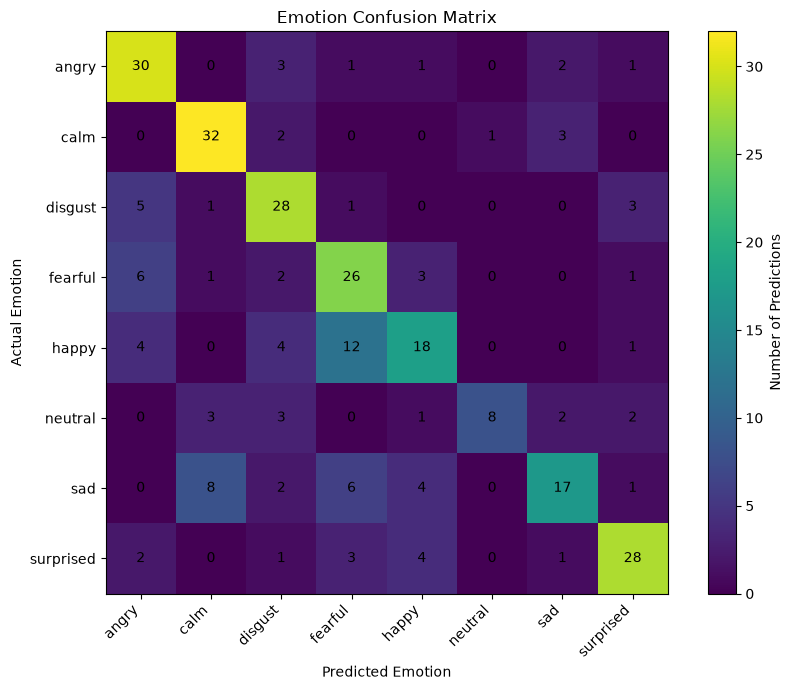

In [57]:
# ============================================================
# DASHBOARD HEADER
# ============================================================

display(
    HTML(
        """
        <div style="
            background-color:#1f2937;
            padding:25px;
            border-radius:12px;
            margin-bottom:20px;
        ">
            <h1 style="
                color:white;
                margin:0;
                font-size:30px;
            ">
                CallConnect — Analytics Engineering Dashboard
            </h1>

            <p style="
                color:#d1d5db;
                margin:8px 0 0 0;
                font-size:15px;
            ">
                Model performance • Business impact • Error analysis •
                Decision threshold analysis
            </p>
        </div>
        """
    )
)

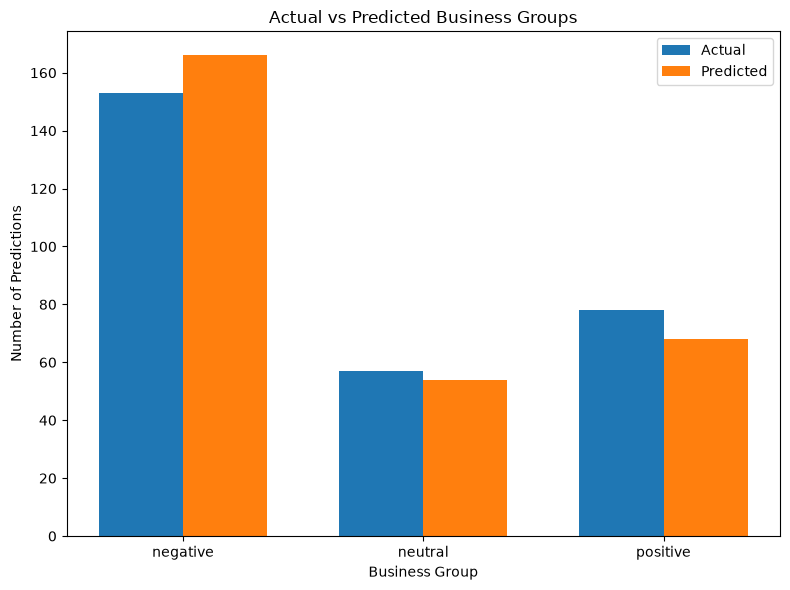

In [60]:
# ============================================================
# 2. BUSINESS GROUP ACTUAL VS PREDICTED
# ============================================================

group_order = ["negative", "neutral", "positive"]

actual_counts = (
    ae_predictions["actual_group"]
    .value_counts()
    .reindex(group_order, fill_value=0)
)

predicted_counts = (
    ae_predictions["predicted_group"]
    .value_counts()
    .reindex(group_order, fill_value=0)
)

x = np.arange(len(group_order))
width = 0.35

plt.figure(figsize=(8, 6))

plt.bar(
    x - width / 2,
    actual_counts.values,
    width,
    label="Actual"
)

plt.bar(
    x + width / 2,
    predicted_counts.values,
    width,
    label="Predicted"
)

plt.xticks(x, group_order)
plt.ylabel("Number of Predictions")
plt.xlabel("Business Group")
plt.title("Actual vs Predicted Business Groups")
plt.legend()

plt.tight_layout()
plt.show()

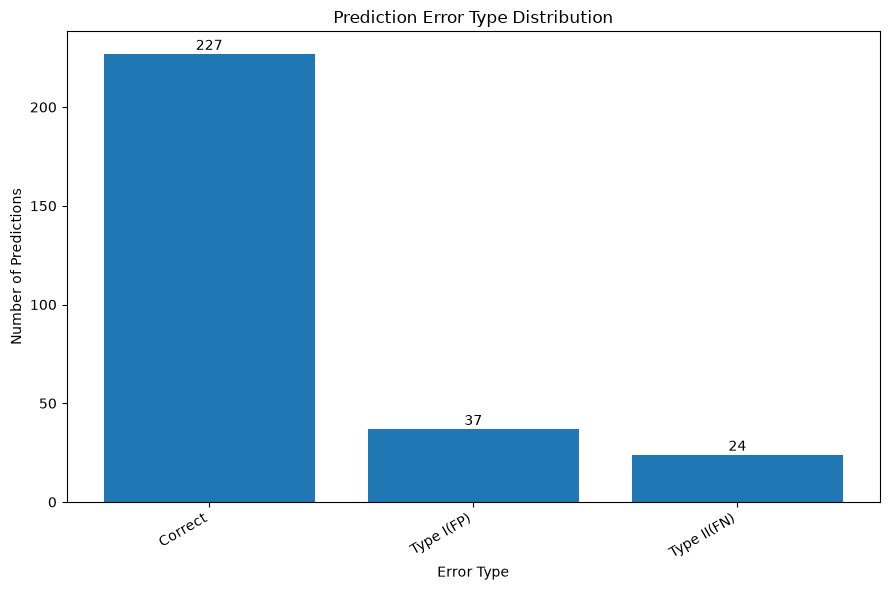

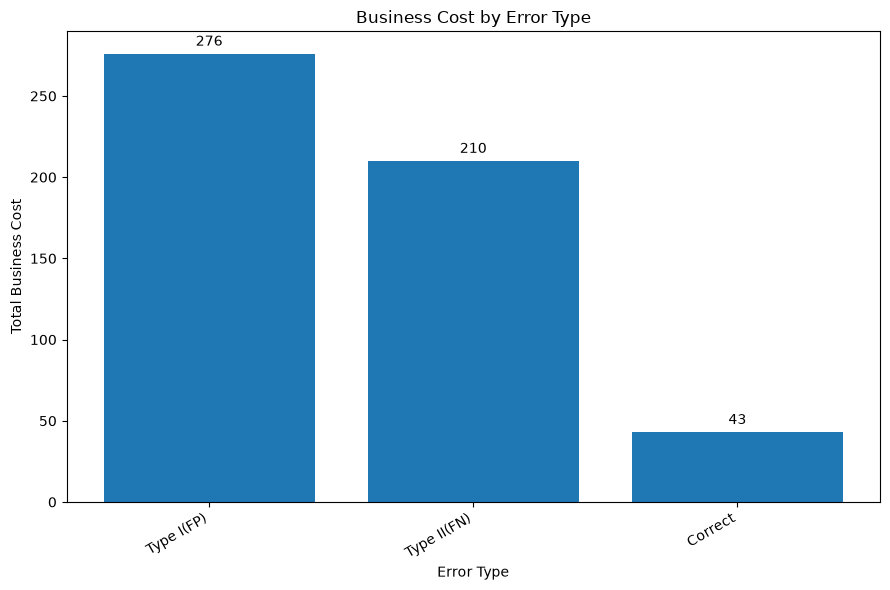

In [61]:
# ============================================================
# 3. ERROR TYPE DISTRIBUTION
# ============================================================

error_counts = (
    ae_predictions["error_type"]
    .value_counts()
)

plt.figure(figsize=(9, 6))

plt.bar(
    error_counts.index,
    error_counts.values
)

plt.title("Prediction Error Type Distribution")
plt.xlabel("Error Type")
plt.ylabel("Number of Predictions")

plt.xticks(
    rotation=30,
    ha="right"
)

for i, value in enumerate(error_counts.values):
    plt.text(
        i,
        value + 2,
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 4. BUSINESS COST BY ERROR TYPE
# ============================================================

cost_by_error = (
    ae_predictions
    .groupby("error_type")["unit_cost"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))

plt.bar(
    cost_by_error.index,
    cost_by_error.values
)

plt.title("Business Cost by Error Type")
plt.xlabel("Error Type")
plt.ylabel("Total Business Cost")

plt.xticks(
    rotation=30,
    ha="right"
)

for i, value in enumerate(cost_by_error.values):
    plt.text(
        i,
        value + 5,
        str(round(value, 2)),
        ha="center"
    )

plt.tight_layout()
plt.show()

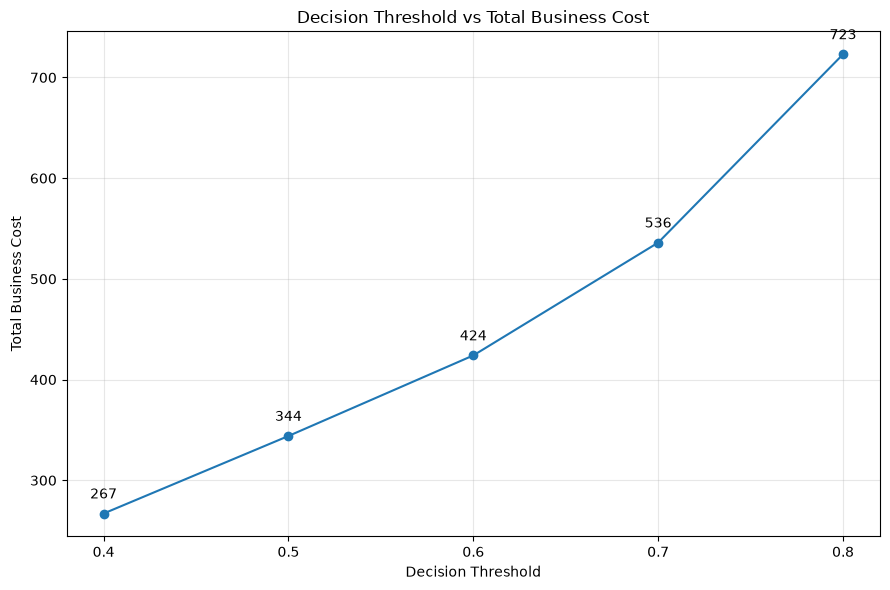

In [62]:
# ============================================================
# 5. DECISION THRESHOLD VS TOTAL BUSINESS COST
# ============================================================

threshold_df = threshold_df.sort_values("threshold")

plt.figure(figsize=(9, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["total_cost"],
    marker="o"
)

plt.title("Decision Threshold vs Total Business Cost")
plt.xlabel("Decision Threshold")
plt.ylabel("Total Business Cost")

plt.xticks(threshold_df["threshold"])

for x, y in zip(
    threshold_df["threshold"],
    threshold_df["total_cost"]
):
    plt.text(
        x,
        y + 15,
        str(round(y, 0)),
        ha="center"
    )

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()